In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Loaded All Datasets

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')

orders = pd.read_csv('olist_orders_dataset.csv')

order_items = pd.read_csv('olist_order_items_dataset.csv')

payments = pd.read_csv('olist_order_payments_dataset.csv')

products = pd.read_csv('olist_products_dataset.csv')

reviews = pd.read_csv('olist_order_reviews_dataset.csv')

sellers = pd.read_csv('olist_sellers_dataset.csv')

category = pd.read_csv('product_category_name_translation.csv')

In [3]:
customers.shape


(99441, 5)

In [4]:
orders.shape

(99441, 8)

In [5]:
order_items.shape

(112650, 7)

In [6]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [9]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
# Data Type Conversion

In [11]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [12]:
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

In [13]:
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

# Mergeing Tables

In [14]:
#Orders + Customers
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [15]:
#Order Items
df = df.merge(
    order_items,
    on='order_id',
    how='left'
)

In [16]:
#Add Payments
df = df.merge(
    payments,
    on='order_id',
    how='left'
)

In [17]:
#Add Products
df = df.merge(
    products,
    on='product_id',
    how='left'
)

In [18]:
df = df.merge(
    reviews,
    on='order_id',
    how='left'
)

In [19]:
#Add Category Names
df = df.merge(
    category,
    on='product_category_name',
    how='left'
)

# Feature Engineering

In [20]:
#Delivery Days
df['delivery_days'] = (
    df['order_delivered_customer_date']
    -
    df['order_purchase_timestamp']
).dt.days

In [21]:
#Estimated Delivery Days
df['estimated_days'] = (
    df['order_estimated_delivery_date']
    -
    df['order_purchase_timestamp']
).dt.days

In [22]:
#Delivery Status
df['delivery_status'] = np.where(
    df['delivery_days'] > df['estimated_days'],
    'Delayed',
    'On Time'
)

In [23]:
#Purchase Month
df['purchase_month'] = df[
    'order_purchase_timestamp'
].dt.month

In [24]:
df['purchase_year'] = df[
    'order_purchase_timestamp'
].dt.year

In [25]:
df.shape

(119143, 42)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  object        
 5   order_delivered_carrier_date   117057 non-null  object        
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [27]:
df.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,delivery_days,estimated_days,purchase_month,purchase_year
count,119143,115722,119143,119143.000000,118310.000000,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118146.000000,115722.000000,119143.000000,119143.000000,119143.000000
mean,2017-12-29 18:36:13.115760128,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642240,35033.451298,1.196543,120.646603,20.032387,1.094737,2.941246,172.735135,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,4.015582,12.022589,23.500231,6.033086,2017.535290
min,2016-09-04 21:15:19,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,2016.000000
25%,2017-09-10 20:15:46,2017-09-22 21:54:31.249999872,2017-10-02 00:00:00,11250.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.850000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,4.000000,6.000000,18.000000,3.000000,2017.000000
50%,2018-01-17 11:59:12,2018-02-01 03:17:55,2018-02-14 00:00:00,24240.000000,1.000000,74.900000,16.280000,1.000000,2.000000,108.160000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,5.000000,10.000000,23.000000,6.000000,2018.000000
75%,2018-05-03 13:18:30,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58475.000000,1.000000,134.900000,21.180000,1.000000,4.000000,189.240000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,5.000000,15.000000,28.000000,8.000000,2018.000000
max,2018-10-17 17:30:18,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,5.000000,209.000000,155.000000,12.000000,2018.000000
std,NaN,NaN,NaN,29823.198969,0.699489,184.109691,15.836850,0.730141,2.777848,267.776077,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,1.400436,9.454922,8.872370,3.233819,0.505591


# Numerical Analysis

In [28]:
num_cols = df.select_dtypes(include=np.number)

In [29]:
#SKEWNESS
skewness = num_cols.skew().sort_values(
    ascending=False
)

print(skewness)

payment_sequential            15.775506
payment_value                 13.965989
price                          7.892574
order_item_id                  7.551727
freight_value                  5.543384
delivery_days                  3.846872
product_weight_g               3.583092
product_height_cm              2.238962
product_description_lenght     2.012156
product_photos_qty             1.908750
product_length_cm              1.745685
product_width_cm               1.707171
payment_installments           1.619820
estimated_days                 1.020433
customer_zip_code_prefix       0.785474
purchase_month                 0.203728
purchase_year                 -0.221161
product_name_lenght           -0.904894
review_score                  -1.245767
dtype: float64


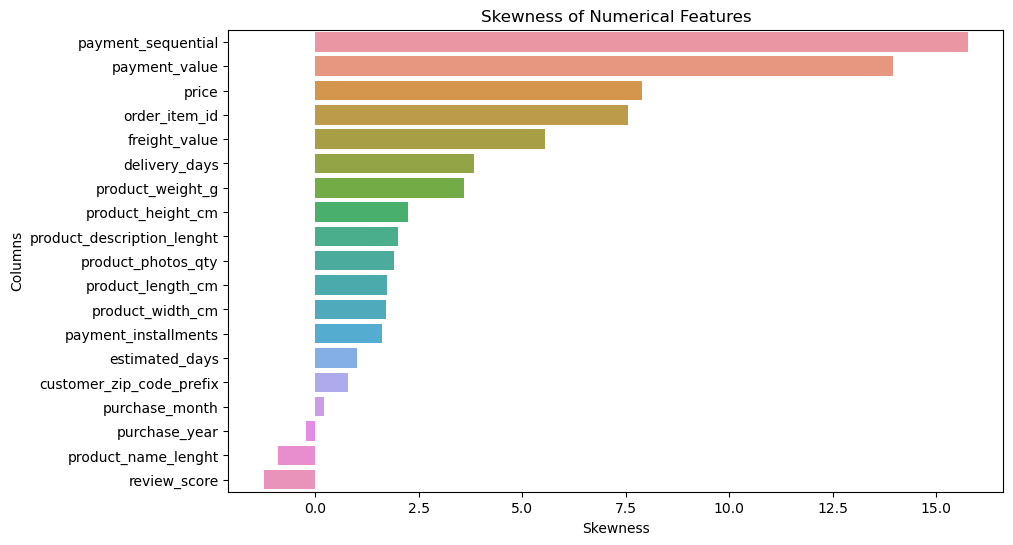

In [30]:
skewness_df = pd.DataFrame({
    'Columns': skewness.index,
    'Skewness': skewness.values
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=skewness_df,
    x='Skewness',
    y='Columns'
)

plt.title('Skewness of Numerical Features')

plt.show()

In [31]:
num_cols.kurtosis()

customer_zip_code_prefix       -0.781026
order_item_id                 103.354815
price                         119.154943
freight_value                  57.635327
payment_sequential            342.283009
payment_installments            2.506545
payment_value                 500.363196
product_name_lenght             0.149508
product_description_lenght      4.929932
product_photos_qty              4.820079
product_weight_g               16.018260
product_length_cm               3.678566
product_height_cm               7.277878
product_width_cm                4.553016
review_score                    0.119050
delivery_days                  39.949146
estimated_days                  5.376021
purchase_month                 -0.985128
purchase_year                  -1.748338
dtype: float64

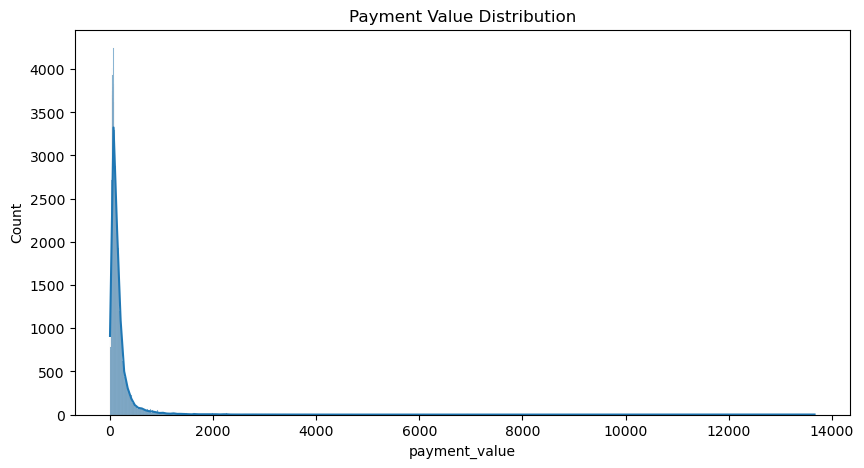

'The payment value distribution is heavily concentrated toward lower transaction amounts, while only a few customers make very\nlarge purchases. This indicates that the business primarily operates on high transaction volume rather than high-value individual\nsales.'

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['payment_value'],
    kde=True
)

plt.title('Payment Value Distribution')

plt.show()

'''The payment value distribution is heavily concentrated toward lower transaction amounts, while only a few customers make very
large purchases. This indicates that the business primarily operates on high transaction volume rather than high-value individual
sales.'''


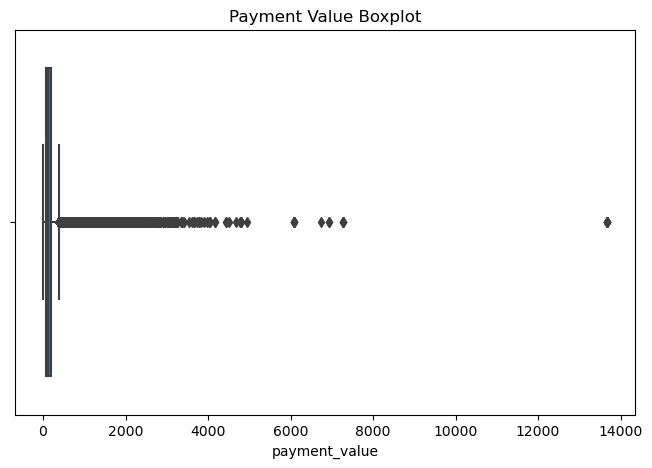

'The boxplot reveals several extreme payment values outside the normal range, indicating the presence of outliers. \nThese outliers may represent premium purchases, bulk orders, or unusual customer buying behavior.'

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['payment_value']
)

plt.title('Payment Value Boxplot')

plt.show()

'''The boxplot reveals several extreme payment values outside the normal range, indicating the presence of outliers. 
These outliers may represent premium purchases, bulk orders, or unusual customer buying behavior.'''

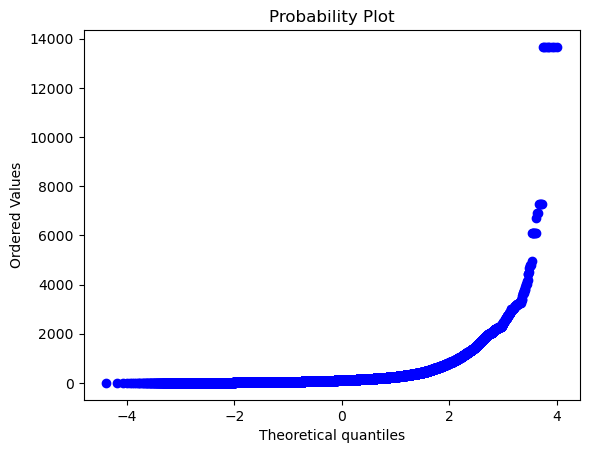

In [34]:
stats.probplot(
    df['payment_value'],
    dist='norm',
    plot=plt
)

plt.show()

# IQR Outlier Detection

In [35]:
#IQR = Q3-Q1
Q1 = df['payment_value'].quantile(0.25)

Q3 = df['payment_value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-131.73500000000004
381.82500000000005


#Outliers 

In [36]:
outliers = df[
    (df['payment_value'] < lower_bound)
    |
    (df['payment_value'] > upper_bound)
]

outliers.shape

(9638, 42)

# Removeing Outliers

In [37]:
df_no_outliers = df[
    (df['payment_value'] >= lower_bound)
    &
    (df['payment_value'] <= upper_bound)
]

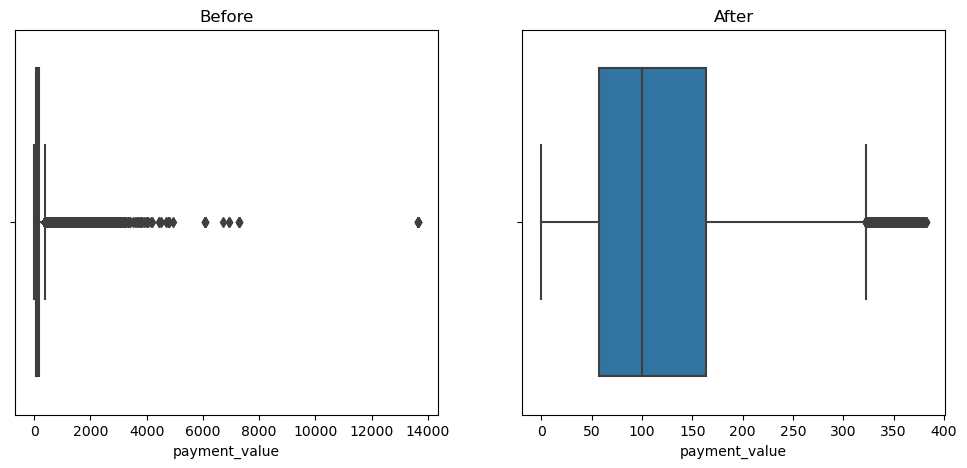

In [38]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    x=df['payment_value'],
    ax=ax[0]
)

ax[0].set_title('Before')

sns.boxplot(
    x=df_no_outliers['payment_value'],
    ax=ax[1]
)

ax[1].set_title('After')

plt.show()

# Log Transformation

In [39]:
df['log_payment'] = np.log1p(
    df['payment_value']
)

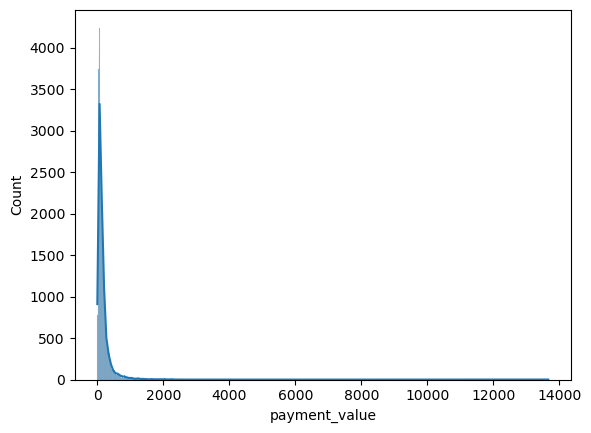

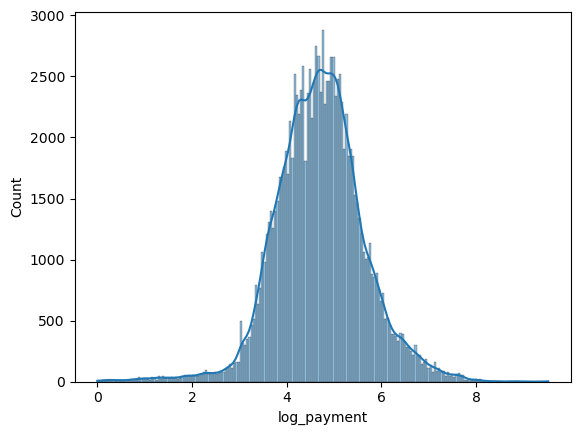

In [40]:
sns.histplot(
    df['payment_value'],
    kde=True
)

plt.show()
sns.histplot(
    df['log_payment'],
    kde=True
)

plt.show()

Log transformation helped reduce the skewness in payment values and created a more balanced distribution, making the data more suitable for analytical modeling and visualization.

# Univariate Analysis

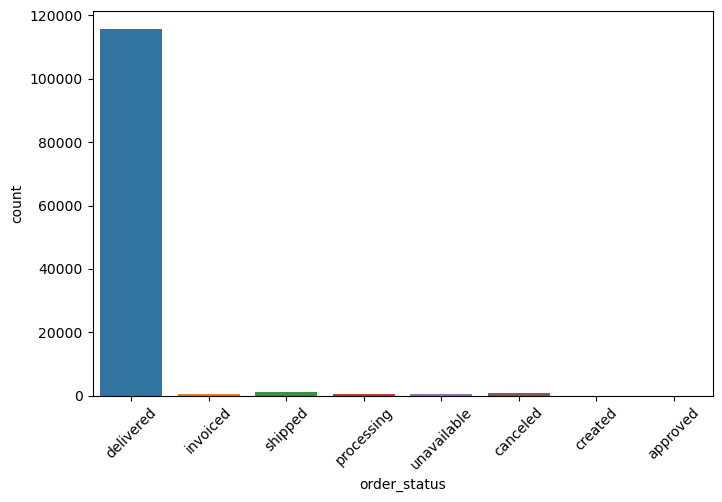

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='order_status'
)

plt.xticks(rotation=45)

plt.show()

Most orders were successfully delivered, indicating strong operational performance and order fulfillment efficiency. Only a small percentage of orders were canceled or unavailable.

# Payment Type

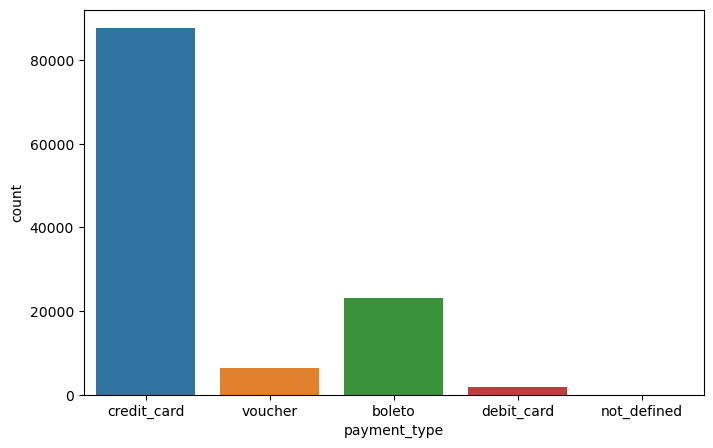

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='payment_type'
)

plt.show()

# Review Scores

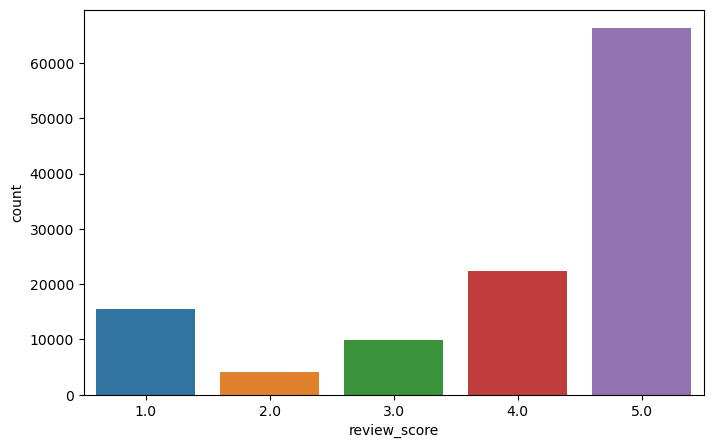

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='review_score'
)

plt.show()

A large proportion of customers provided high review scores, indicating overall positive customer satisfaction with the platform, product quality, and delivery experience.

# Monthly Revenue Trend

In [44]:
monthly_sales = df.groupby(
    'purchase_month'
)['payment_value'].sum().reset_index()

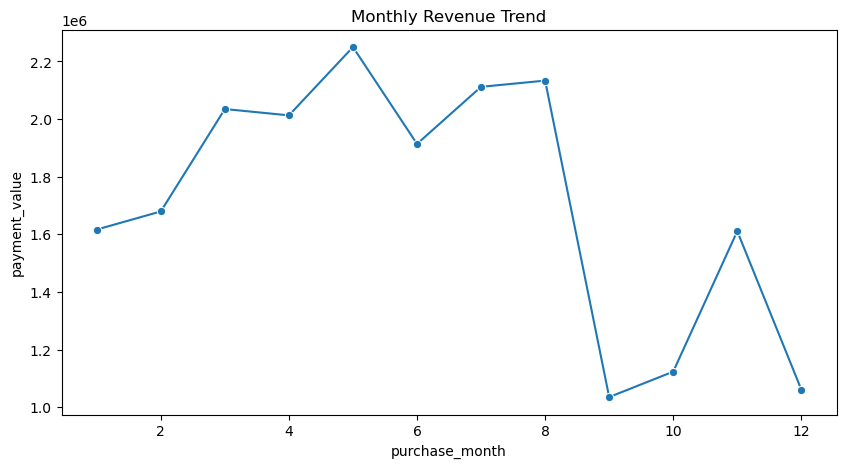

In [45]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x='purchase_month',
    y='payment_value',
    marker='o'
)

plt.title('Monthly Revenue Trend')

plt.show()

Monthly sales trends show fluctuations throughout the year, with certain months generating significantly higher revenue. These peaks may be influenced by seasonal demand, promotional campaigns, or festive shopping periods.

In [46]:
top_categories = df.groupby(
    'product_category_name_english'
)['payment_value'].sum().sort_values(
    ascending=False
).head(10)

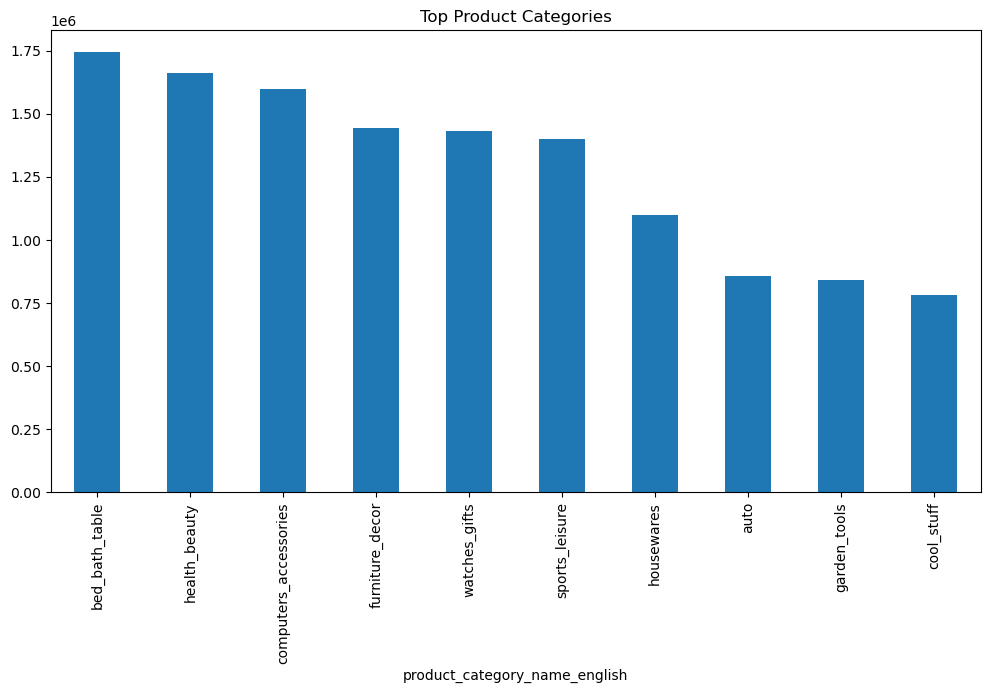

In [47]:
plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title('Top Product Categories')

plt.show()

A small number of product categories contribute the majority of total revenue, indicating that customer demand is concentrated within specific product segments.

# Delivery Analysis

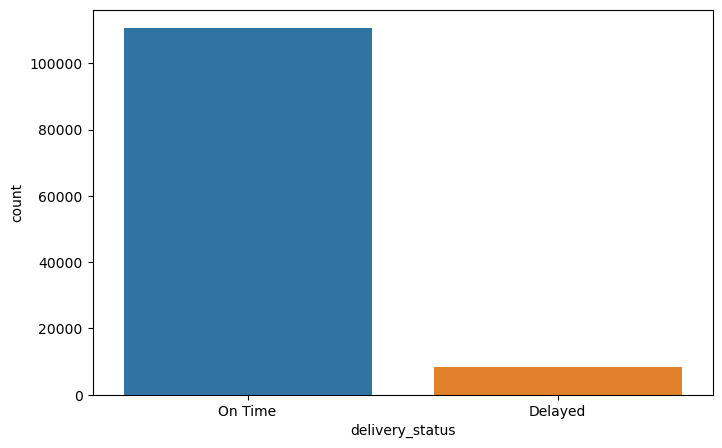

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='delivery_status'
)

plt.show()

# Delay vs Review Score

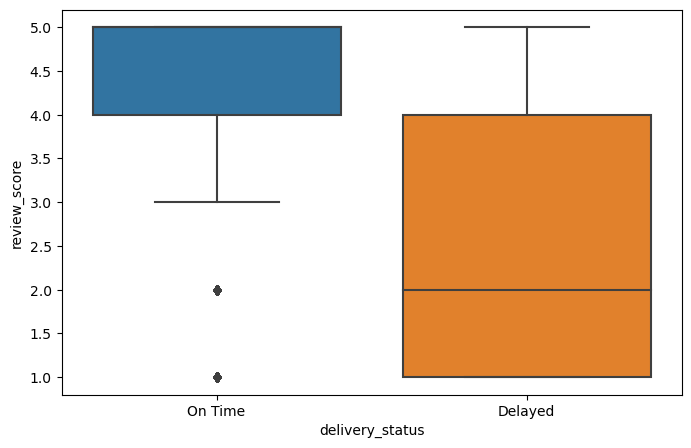

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='delivery_status',
    y='review_score'
)

plt.show()

Most deliveries were completed on time, showing effective logistics management. However, delayed deliveries still represent a significant operational challenge that may impact customer satisfaction.

# State-wise Revenue

In [50]:
state_sales = df.groupby(
    'customer_state'
)['payment_value'].sum().sort_values(
    ascending=False
).head(10)

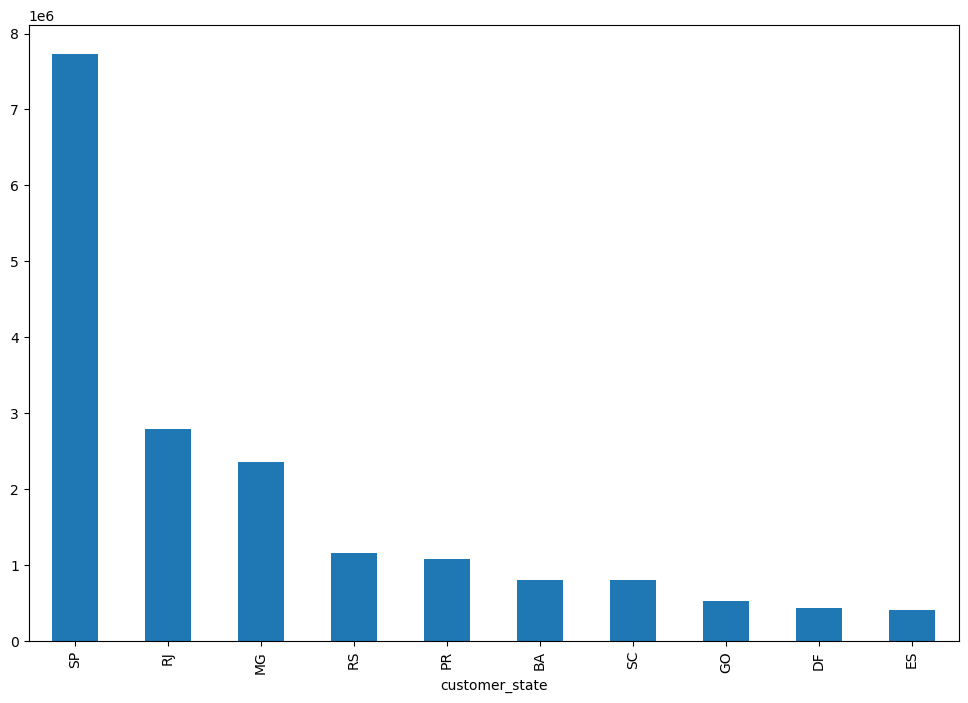

In [51]:
plt.figure(figsize=(12,8))

state_sales.plot(kind='bar')

plt.show()

Revenue generation is concentrated in a few states, indicating that certain regions have significantly higher customer activity and purchasing power compared to others.

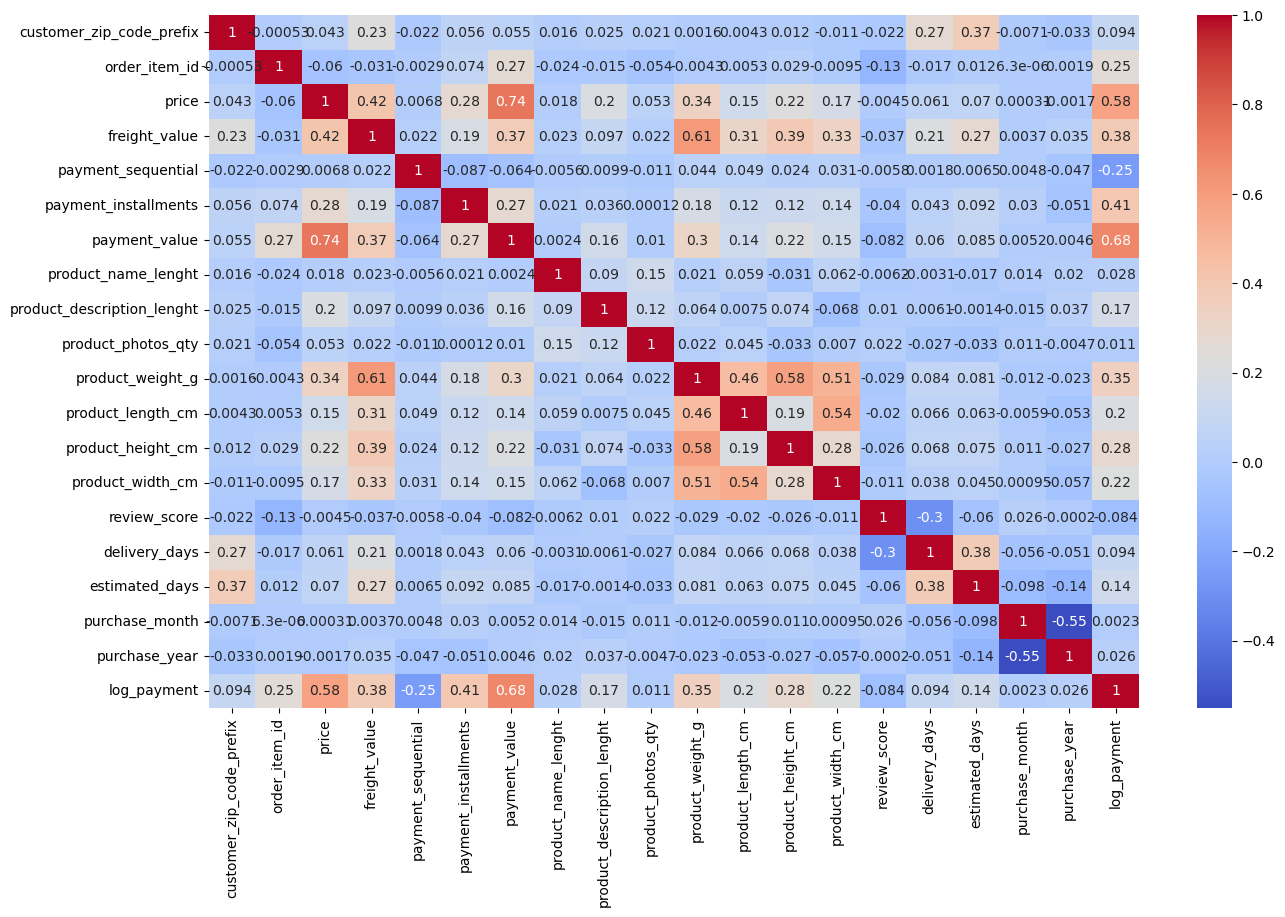

In [52]:
plt.figure(figsize=(15,9))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Correlation analysis shows that some numerical variables have moderate relationships with each other, while most features remain relatively independent. Payment value and freight charges show a positive relationship, suggesting shipping costs increase with order value.

# RFM ANALYSIS

In [54]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [56]:
#RFM Table
rfm = df.groupby('customer_unique_id').agg({

    'order_purchase_timestamp': lambda x:
    (snapshot_date - x.max()).days,

    'order_id': 'nunique',

    'payment_value': 'sum'

}).reset_index()

In [57]:
rfm.columns = [
    'customer_id',
    'Recency',
    'Frequency',
    'Monetary'
]

In [59]:
#R Score
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [60]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [61]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [62]:
#Combine Scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    +
    rfm['F_Score'].astype(str)
    +
    rfm['M_Score'].astype(str)
)

In [63]:
def customer_segment(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['R_Score'] == 4:
        return 'Loyal Customers'

    elif row['M_Score'] == 4:
        return 'Big Spenders'

    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(
    customer_segment,
    axis=1
)

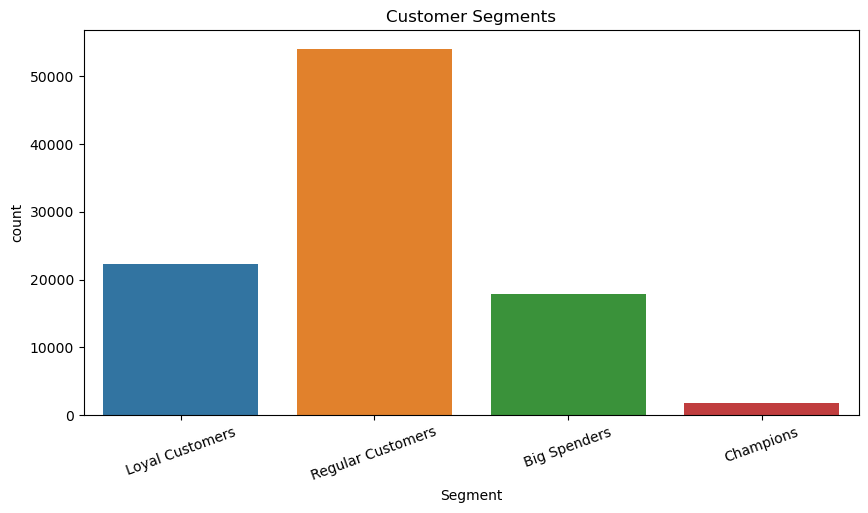

In [65]:
#Segment Visualization
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.xticks(rotation=20)

plt.title('Customer Segments')

plt.show()

RFM analysis was used to segment customers based on purchase recency, order frequency, and monetary contribution. This helped identify high-value customer groups such as loyal customers and big spenders for targeted business strategies.

In [66]:
snapshot_date = df['order_purchase_timestamp'].max()

In [67]:
customer_df = df.groupby(
    'customer_unique_id'
).agg({

    'order_id':'nunique',

    'payment_value':'mean',

    'delivery_days':'mean',

    'review_score':'mean',

    'order_purchase_timestamp':'max'

}).reset_index()

In [68]:
customer_df.columns = [

    'customer_id',

    'order_frequency',

    'avg_payment',

    'avg_delivery_days',

    'avg_review_score',

    'last_purchase_date'
]

In [69]:
customer_df['recency'] = (
    snapshot_date
    -
    customer_df['last_purchase_date']
).dt.days

In [70]:
customer_df['churn'] = np.where(
    customer_df['recency'] > 90,
    1,
    0
)

In [71]:
customer_df['churn'].value_counts()

churn
1    86432
0     9664
Name: count, dtype: int64